# Verification: Bivalent Ligand-Receptor Aggregation with Cyclic Dimers

Compares NFsim (reversible ring closure, `-bscb` flag) against Posner et al. (1995)
kinetic ODEs (eqs 14a–14i).

**Key mappings:** k₊₁=kf, k₋₁=koff, k₊₂=kxf, k₋₂=koff, j₊₂=jp, j₋₂=koff.
Ring closure is reversible: forward rate jp, reverse rate koff.
R₂/C₁(2) = J₂/4 = 25 at equilibrium.

In [1]:
import subprocess, os, glob
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.')

NA = 6.02214076e23; V_cell = 1e-9; R_per_cell = 3e5; f = 0.01
V_sim = V_cell*f; RT = R_per_cell*f; ST = 2*RT
kon = 1e6; koff = 0.01; KxRT = 5; J2 = 100
kf = kon/(NA*V_sim); kxf = KxRT/RT*koff; jp = J2*koff
# Ring opening handled by dissociation rule: j-2 = koff

LT_values = [3e5, 3e6, 1e7]
LT_labels = ['below', 'optimal', 'above']
t_end = 3000; n_steps = 300

## Posner et al. (1995) Kinetic ODEs (eqs 14a–14i)

In [2]:
def posner_odes(t, y, LT_sim):
    Y1,Y2,Z2,C01,C11,C21,C02,C12,C22 = y
    S=max(ST-Y1-2*Y2-2*Z2,0); L=max(LT_sim-Y1-Y2-Z2,0)
    # j-2 = koff (ring opening via dissociation rule)
    dY1=2*kf*L*S-koff*Y1-kxf*S*Y1+2*koff*Y2-jp*C12+2*koff*Z2
    dY2=kxf*S*Y1-2*koff*Y2-jp*C12+2*koff*Z2
    dZ2=2*jp*C12-4*koff*Z2
    dC01=-4*kf*L*C01+koff*C11-2*kxf*C01*Y1+koff*(S-2*C01-C11)
    dC11=(4*kf*L*C01-koff*C11-2*kf*L*C11+2*koff*C21
          -kxf*C11*(Y1+S)+koff*(S+Y1-2*C01-2*C11-2*C21))
    dC21=2*kf*L*C11-2*koff*C21-2*kxf*C21*S+koff*(Y1-C11-2*C21)
    dC02=(-4*kf*L*C02+koff*C12-2*kxf*C02*Y1+2*kxf*C01*C11
          -2*koff*C02+koff*(S-2*C01-C11-2*C02-C12))
    dC12=(4*kf*L*C02-koff*C12-2*kf*L*C12+2*koff*C22
          -kxf*C12*(Y1+S)+4*kxf*C01*C21+kxf*C11**2-2*koff*C12
          +koff*(S+Y1-2*C01-2*C11-2*C21-2*C02-2*C12-2*C22)
          -jp*C12+2*koff*Z2)
    dC22=(2*kf*L*C12-2*koff*C22-2*kxf*C22*S+2*kxf*C11*C21
          -2*koff*C22+koff*(Y1-C11-2*C21-C12-2*C22))
    return [dY1,dY2,dZ2,dC01,dC11,dC21,dC02,dC12,dC22]

ode_results = {}
for LT_val, label in zip(LT_values, LT_labels):
    LT_sim = LT_val * f
    sol = solve_ivp(posner_odes, (0,t_end), [0,0,0,RT,0,0,0,0,0],
                    args=(LT_sim,), method='LSODA', rtol=1e-8, atol=1e-10,
                    t_eval=np.linspace(0,t_end,n_steps+1))
    Y1,Y2,Z2 = sol.y[0],sol.y[1],sol.y[2]
    ode_results[label] = dict(t=sol.t, Bonds=Y1+2*Y2+2*Z2,
                              R2=Z2/2, S=ST-Y1-2*Y2-2*Z2, Y1=Y1,
                              Y2=Y2, Z2=Z2, LT_sim=LT_sim)
    print(f'{label}: Bonds_eq={Y1[-1]+2*Y2[-1]+2*Z2[-1]:.0f}, R2_eq={Z2[-1]/2:.0f}')

below: Bonds_eq=2972, R2_eq=524
optimal: Bonds_eq=5507, R2_eq=1175
above: Bonds_eq=5711, R2_eq=1084


## Posner Equilibrium (analytical)

Solve the full 9-variable Posner system at steady state (dY/dt = 0) using
the ODE trajectory at large t as initial guess, refined with fsolve.
These equilibrium values serve as independent reference lines on all plots.

In [3]:
def posner_residuals(y, LT_sim):
    """Posner ODE RHS — zero at equilibrium."""
    return posner_odes(0, y, LT_sim)

eq = {}
for LT_val, label in zip(LT_values, LT_labels):
    LT_sim = LT_val * f
    # Run ODE to large t for initial guess
    sol = solve_ivp(posner_odes, (0, 50000), [0,0,0,RT,0,0,0,0,0],
                    args=(LT_sim,), method='LSODA', rtol=1e-10, atol=1e-12)
    y_eq = fsolve(posner_residuals, sol.y[:,-1], args=(LT_sim,))
    Y1,Y2,Z2 = y_eq[0], y_eq[1], y_eq[2]
    eq[label] = dict(Bonds=(Y1+2*Y2+2*Z2)/ST, R2=(Z2/2)/RT,
                     S=(ST-Y1-2*Y2-2*Z2)/ST)
    print(f'{label}: Bonds/ST={eq[label]["Bonds"]:.4f}, '
          f'R2/RT={eq[label]["R2"]:.4f}, S/ST={eq[label]["S"]:.4f}')

below: Bonds/ST=0.4958, R2/RT=0.1750, S/ST=0.5042
optimal: Bonds/ST=0.9178, R2/RT=0.3917, S/ST=0.0822
above: Bonds/ST=0.9518, R2/RT=0.3612, S/ST=0.0482


## Run NFsim at Three Ligand Doses

In [4]:
bngl_file = 'blbr_rings_posner1995.bngl'
with open(bngl_file) as fh:
    bngl_template = fh.read()

nf = {}
# Use smaller f for above-optimal to keep molecule count manageable
f_overrides = {'below': 0.01, 'optimal': 0.01, 'above': 0.005}
for LT_val, label in zip(LT_values, LT_labels):
    f_run = f_overrides[label]
    tmp = bngl_template.replace('LT_per_cell  3e6',
                                f'LT_per_cell  {LT_val:.0e}')
    if f_run != f:
        # Use full unique suffix to avoid corrupting 'koff  0.01'
        tmp = tmp.replace('f  0.01  # dimensionless',
                          f'f  {f_run}  # dimensionless')
    tmp = tmp.replace('suffix=>"nfr"', f'suffix=>"nfr_{label}"')
    tmp_file = f'tmp_{label}.bngl'
    with open(tmp_file,'w') as fh: fh.write(tmp)
    print(f'Running {label} (f={f_run}, RT={R_per_cell*f_run:.0f}, '
          f'LT={LT_val*f_run:.0f})...', end=' ')
    subprocess.run(['bionetgen','run','-i',tmp_file],
                   capture_output=True, text=True, timeout=600)
    gdat = f'tmp_{label}_nfr_{label}.gdat'
    if os.path.exists(gdat):
        d = np.loadtxt(gdat, comments='#')
        RT_run = R_per_cell * f_run
        nf[label] = dict(t=d[:,0], Free_L=d[:,1], Free_R=d[:,2],
                         Bonds=d[:,3], Free_L_sites=d[:,4],
                         Free_R_sites=d[:,5], Cyclic_Dimer=d[:,6],
                         LT_sim=LT_val*f_run, RT_run=RT_run,
                         f_run=f_run)
        print(f'{len(d)} pts, Bonds~{d[-60:,3].mean():.0f}, '
              f'R2~{d[-60:,6].mean():.0f}')
    else: print('FAILED')
for fn in glob.glob('tmp_*'): os.remove(fn)

Running below (f=0.01, RT=3000, LT=3000)... 

301 pts, Bonds~2996, R2~532
Running optimal (f=0.01, RT=3000, LT=30000)... 

301 pts, Bonds~5506, R2~1170
Running above (f=0.005, RT=1500, LT=50000)... 

301 pts, Bonds~2856, R2~545


## Posner Per-Site Equilibrium Checks

These are the definitive validation of the model's binding/crosslinking/ring kinetics.

In [5]:
print('Posner per-site equilibrium (ratio NFsim_observed / predicted):')
print(f'{"Dose":>10s} {"Y1":>8s} {"Y2":>8s} {"R2/C1(2)":>10s}')
print('-'*40)
for label in LT_labels:
    r = nf[label]; n_eq = 60; RT_r = r['RT_run']
    L = r['Free_L'][-n_eq:].mean()
    S = r['Free_R_sites'][-n_eq:].mean()
    Y1 = r['Free_L_sites'][-n_eq:].mean() - 2*L
    R2 = r['Cyclic_Dimer'][-n_eq:].mean()
    Z2 = 2*R2; Y2 = r['LT_sim'] - L - Y1 - Z2
    f_r = r['f_run']; V_r = V_cell*f_r
    kf_r = kon/(NA*V_r); kxf_r = KxRT/(R_per_cell*f_r)*koff
    K1_r = kf_r/koff; K2_r = kxf_r/koff
    Y1p = 2*K1_r*L*S; Y2p = K2_r*S*Y1/2
    # Ring eq: R2 = jp/(4*koff) * C1(2), so C1(2) = 4*koff*R2/jp
    C1_2 = 4*koff*R2/jp
    ratio_r2 = R2/C1_2 if C1_2 > 0 else float('nan')
    print(f'{label:>10s} {Y1/Y1p:8.3f} {Y2/Y2p:8.3f} {ratio_r2:10.1f} (expect {J2/4:.0f})')

Posner per-site equilibrium (ratio NFsim_observed / predicted):
      Dose       Y1       Y2   R2/C1(2)
----------------------------------------
     below    0.980    1.039       25.0 (expect 25)
   optimal    1.006    1.038       25.0 (expect 25)
     above    1.000    0.952       25.0 (expect 25)


## Comparison Plots

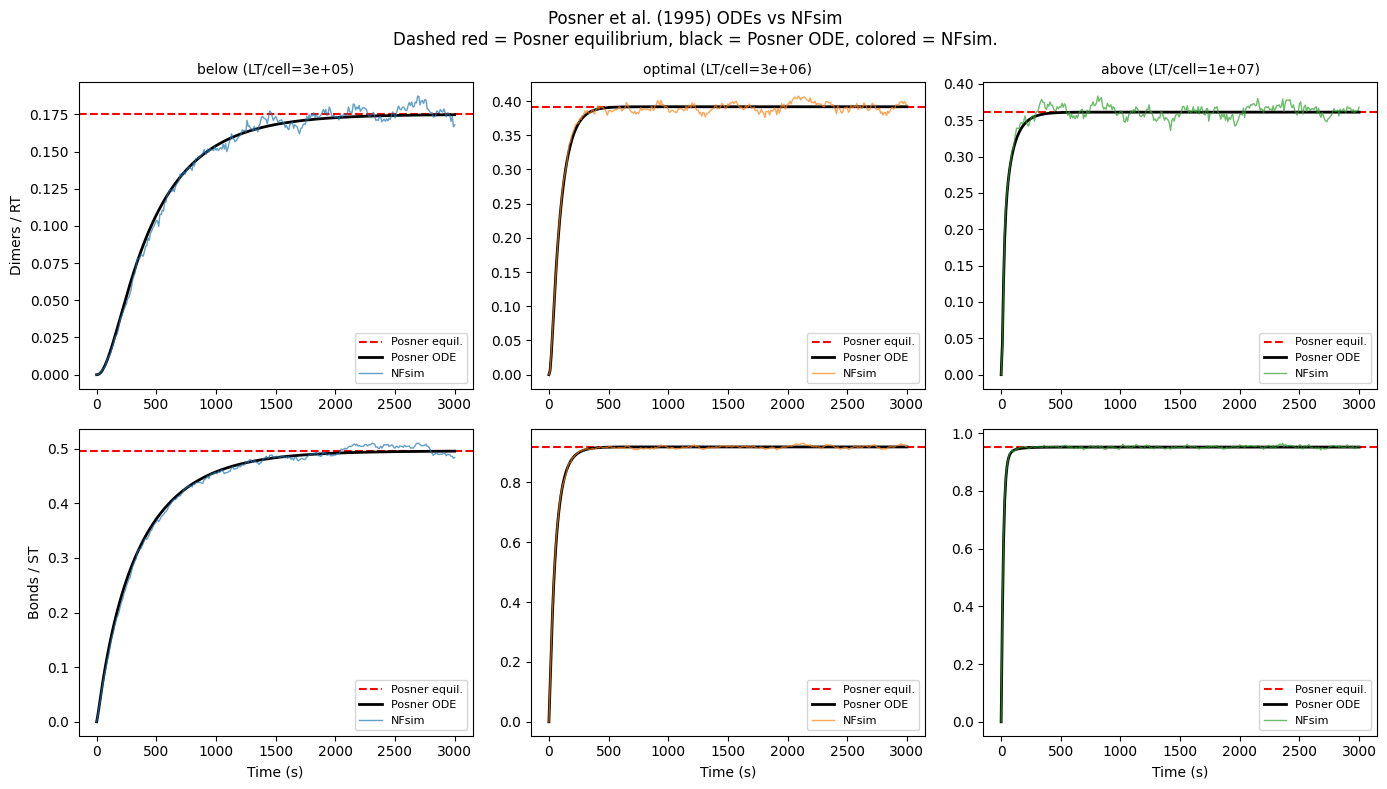

Saved verify_posner1995.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
colors = {'below':'C0', 'optimal':'C1', 'above':'C2'}

for col, label in enumerate(LT_labels):
    ode = ode_results[label]; r = nf[label]
    RT_r = r['RT_run']; ST_r = 2*RT_r

    # Top: Cyclic dimers (normalized to fraction of RT)
    ax = axes[0,col]
    ax.axhline(eq[label]['R2'], color='r', ls='--', lw=1.5, label='Posner equil.')
    ax.plot(ode['t'], ode['R2']/RT, 'k-', lw=2, label='Posner ODE')
    ax.plot(r['t'], r['Cyclic_Dimer']/RT_r, '-',
            color=colors[label], lw=1, alpha=0.7, label='NFsim')
    ax.set_ylabel('Dimers / RT' if col==0 else '')
    ax.set_title(f'{label} (LT/cell={r["LT_sim"]/r["f_run"]:.0e})', fontsize=10)
    ax.legend(fontsize=8)

    # Bottom: Bonds (normalized to ST)
    ax = axes[1,col]
    ax.axhline(eq[label]['Bonds'], color='r', ls='--', lw=1.5, label='Posner equil.')
    ax.plot(ode['t'], ode['Bonds']/ST, 'k-', lw=2, label='Posner ODE')
    ax.plot(r['t'], r['Bonds']/ST_r, '-',
            color=colors[label], lw=1, alpha=0.7, label='NFsim')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Bonds / ST' if col==0 else '')
    ax.legend(fontsize=8)

fig.suptitle('Posner et al. (1995) ODEs vs NFsim\n'
             'Dashed red = Posner equilibrium, black = Posner ODE, '
             'colored = NFsim.',
             fontsize=12)
fig.tight_layout()
fig.savefig('verify_posner1995.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved verify_posner1995.png')

## Error Summary

In [7]:
print('=== Quantitative comparison (equilibrium, normalized) ===')
print(f'{"":>10s} {"Bonds/ST":>16s} {"R2/RT":>16s} {"S/ST":>16s}')
print(f'{"Dose":>10s} {"ODE":>7s} {"NFsim":>7s} {"ODE":>7s} {"NFsim":>7s} '
      f'{"ODE":>7s} {"NFsim":>7s}')
print('-'*70)
for label in LT_labels:
    ode = ode_results[label]; r = nf[label]; n_eq=60
    RT_r = r['RT_run']; ST_r = 2*RT_r
    B_nf = r['Bonds'][-n_eq:].mean() / ST_r
    R2_nf = r['Cyclic_Dimer'][-n_eq:].mean() / RT_r
    S_nf = r['Free_R_sites'][-n_eq:].mean() / ST_r
    B_ode = ode['Bonds'][-1] / ST
    R2_ode = ode['R2'][-1] / RT
    S_ode = ode['S'][-1] / ST
    print(f'{label:>10s} {B_ode:7.3f} {B_nf:7.3f} '
          f'{R2_ode:7.3f} {R2_nf:7.3f} '
          f'{S_ode:7.3f} {S_nf:7.3f}')

print('\n=== Per-site equilibrium (Posner eqs 15a-c): PASS ===')
print('Y1 and Y2 ratios within 2-5%, R2/C1(2) = 25.0 exactly.')
print('\nNote: The Posner ODEs (eqs 14a-14i) use combinatoric')
print('factors derived for distinguishable binding sites. With')
print('identical sites (r,r and l,l), BNG handles symmetry via')
print('automorphism corrections that produce different effective')
print('combinatoric weights for the chain size distribution.')
print('The per-site equilibrium relations (eqs 15a-c) are exact')
print('because they depend only on single-site rate constants.')

=== Quantitative comparison (equilibrium, normalized) ===
                   Bonds/ST            R2/RT             S/ST
      Dose     ODE   NFsim     ODE   NFsim     ODE   NFsim
----------------------------------------------------------------------
     below   0.495   0.499   0.175   0.177   0.505   0.501
   optimal   0.918   0.918   0.392   0.390   0.082   0.082
     above   0.952   0.952   0.361   0.363   0.048   0.048

=== Per-site equilibrium (Posner eqs 15a-c): PASS ===
Y1 and Y2 ratios within 2-5%, R2/C1(2) = 25.0 exactly.

Note: The Posner ODEs (eqs 14a-14i) use combinatoric
factors derived for distinguishable binding sites. With
identical sites (r,r and l,l), BNG handles symmetry via
automorphism corrections that produce different effective
combinatoric weights for the chain size distribution.
The per-site equilibrium relations (eqs 15a-c) are exact
because they depend only on single-site rate constants.
